In [103]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [104]:
df = pd.read_csv("consumer_behavior_dataset.csv")
df.head(5)
# Adanya gender Other, bagi saya biarkan saja

,user_id,product_id,category,price,discount_applied,payment_method,purchase_date,pages_visited,time_spent,add_to_cart,abandoned_cart,rating,review_text,sentiment_score,age,gender,income_level,location,purchase_decision
0,b93e568c-81fc-4db8-8509-2940e261b2f2,6badd48c-5349-444b-9f92-8a27c11ce05f,Clothing,389.23,46.99,Credit Card,2025-01-31 04:07:28,6,955,0,0,4,Start similar morning police quality various m...,0.16,51,Other,Low,Jeremyview,0
1,68c55d68-1074-48af-80ae-b5dad0915b8d,fe635f30-f9bb-4ca9-8a0d-3d6c67e2ae23,Clothing,344.81,9.11,COD,2025-01-21 06:07:28,8,790,1,0,3,Candidate level take evening almost push social.,0.03,54,Male,High,South Amy,1
2,a5adbe49-8208-459a-b72d-1b2960b38ade,e9dc8006-25eb-4aec-9c11-a2b33037b01b,Electronics,180.59,19.37,COD,2025-02-05 00:30:15,3,336,0,0,1,Way nearly value Republican part foot degree i...,0.10,49,Female,Low,West Lisaside,0
3,d0f1b4e1-d647-46d9-b88a-fea1beb8239f,8c7073db-ee68-415b-9686-ae6f068c9d2d,Grocery,415.26,25.18,Debit Card,2025-01-08 16:03:46,4,624,1,0,4,Drive eight upon do work share fear soldier no...,-0.50,20,Male,Low,Lake Deanport,1
4,2d530715-fb4f-40c5-95bb-02367d3c8c2c,864100c8-2502-4717-ba77-4261eae803f8,Electronics,352.82,46.07,PayPal,2025-02-27 19:53:59,4,579,0,0,5,Drug late look state concern personal go second.,-0.10,21,Other,Medium,Gloriaborough,0


In [105]:
df.isnull().sum()

,0
user_id,0
product_id,0
category,0
price,0
discount_applied,0
payment_method,0
purchase_date,0
pages_visited,0
time_spent,0
add_to_cart,0


In [106]:
df.shape

(5000, 19)

In [107]:
kolom_duplikat = []
for i in range(len(df.columns)):
    for j in range(i + 1, len(df.columns)):
        kolom1 = df.columns[i]
        kolom2 = df.columns[j]
        if df[kolom1].equals(df[kolom2]):
            kolom_duplikat.append(f"{kolom1} sama dengan {kolom2}")
print(kolom_duplikat)

[]


In [108]:
df.duplicated().sum()

np.int64(0)

In [109]:
print(df.dtypes)

user_id               object
product_id            object
category              object
price                float64
discount_applied     float64
payment_method        object
purchase_date         object
pages_visited          int64
time_spent             int64
add_to_cart            int64
abandoned_cart         int64
rating                 int64
review_text           object
sentiment_score      float64
age                    int64
gender                object
income_level          object
location              object
purchase_decision      int64
dtype: object


In [110]:
df.describe()

,price,discount_applied,pages_visited,time_spent,add_to_cart,abandoned_cart,rating,sentiment_score,age,purchase_decision
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,250.618432,25.170788,10.531600,618.656800,0.494600,0.247800,2.973200,0.078352,41.545400,0.246800
std,142.209505,14.391818,5.765835,337.057571,0.500021,0.431778,1.419325,0.206702,13.788095,0.431192
min,5.020000,0.020000,1.000000,30.000000,0.000000,0.000000,1.000000,-0.800000,18.000000,0.000000
25%,126.940000,12.807500,5.000000,328.750000,0.000000,0.000000,2.000000,0.000000,30.000000,0.000000
50%,249.620000,25.345000,11.000000,621.000000,0.000000,0.000000,3.000000,0.000000,42.000000,0.000000
75%,372.850000,37.760000,16.000000,910.250000,1.000000,0.000000,4.000000,0.170000,54.000000,0.000000
max,499.940000,49.990000,20.000000,1200.000000,1.000000,1.000000,5.000000,1.000000,65.000000,1.000000


In [111]:
df['purchase_date'] = pd.to_datetime(df['purchase_date']).dt.date
display(df.head())
display(df.info())

,user_id,product_id,category,price,discount_applied,payment_method,purchase_date,pages_visited,time_spent,add_to_cart,abandoned_cart,rating,review_text,sentiment_score,age,gender,income_level,location,purchase_decision
0,b93e568c-81fc-4db8-8509-2940e261b2f2,6badd48c-5349-444b-9f92-8a27c11ce05f,Clothing,389.23,46.99,Credit Card,2025-01-31,6,955,0,0,4,Start similar morning police quality various m...,0.16,51,Other,Low,Jeremyview,0
1,68c55d68-1074-48af-80ae-b5dad0915b8d,fe635f30-f9bb-4ca9-8a0d-3d6c67e2ae23,Clothing,344.81,9.11,COD,2025-01-21,8,790,1,0,3,Candidate level take evening almost push social.,0.03,54,Male,High,South Amy,1
2,a5adbe49-8208-459a-b72d-1b2960b38ade,e9dc8006-25eb-4aec-9c11-a2b33037b01b,Electronics,180.59,19.37,COD,2025-02-05,3,336,0,0,1,Way nearly value Republican part foot degree i...,0.10,49,Female,Low,West Lisaside,0
3,d0f1b4e1-d647-46d9-b88a-fea1beb8239f,8c7073db-ee68-415b-9686-ae6f068c9d2d,Grocery,415.26,25.18,Debit Card,2025-01-08,4,624,1,0,4,Drive eight upon do work share fear soldier no...,-0.50,20,Male,Low,Lake Deanport,1
4,2d530715-fb4f-40c5-95bb-02367d3c8c2c,864100c8-2502-4717-ba77-4261eae803f8,Electronics,352.82,46.07,PayPal,2025-02-27,4,579,0,0,5,Drug late look state concern personal go second.,-0.10,21,Other,Medium,Gloriaborough,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   user_id            5000 non-null   object 
 1   product_id         5000 non-null   object 
 2   category           5000 non-null   object 
 3   price              5000 non-null   float64
 4   discount_applied   5000 non-null   float64
 5   payment_method     5000 non-null   object 
 6   purchase_date      5000 non-null   object 
 7   pages_visited      5000 non-null   int64  
 8   time_spent         5000 non-null   int64  
 9   add_to_cart        5000 non-null   int64  
 10  abandoned_cart     5000 non-null   int64  
 11  rating             5000 non-null   int64  
 12  review_text        5000 non-null   object 
 13  sentiment_score    5000 non-null   float64
 14  age                5000 non-null   int64  
 15  gender             5000 non-null   object 
 16  income_level       5000 

None

In [112]:
df = df.drop(columns=['review_text', 'user_id', 'product_id', 'sentiment_score'])
display(df.head())
display(df.info())

,category,price,discount_applied,payment_method,purchase_date,pages_visited,time_spent,add_to_cart,abandoned_cart,rating,age,gender,income_level,location,purchase_decision
0,Clothing,389.23,46.99,Credit Card,2025-01-31,6,955,0,0,4,51,Other,Low,Jeremyview,0
1,Clothing,344.81,9.11,COD,2025-01-21,8,790,1,0,3,54,Male,High,South Amy,1
2,Electronics,180.59,19.37,COD,2025-02-05,3,336,0,0,1,49,Female,Low,West Lisaside,0
3,Grocery,415.26,25.18,Debit Card,2025-01-08,4,624,1,0,4,20,Male,Low,Lake Deanport,1
4,Electronics,352.82,46.07,PayPal,2025-02-27,4,579,0,0,5,21,Other,Medium,Gloriaborough,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   category           5000 non-null   object 
 1   price              5000 non-null   float64
 2   discount_applied   5000 non-null   float64
 3   payment_method     5000 non-null   object 
 4   purchase_date      5000 non-null   object 
 5   pages_visited      5000 non-null   int64  
 6   time_spent         5000 non-null   int64  
 7   add_to_cart        5000 non-null   int64  
 8   abandoned_cart     5000 non-null   int64  
 9   rating             5000 non-null   int64  
 10  age                5000 non-null   int64  
 11  gender             5000 non-null   object 
 12  income_level       5000 non-null   object 
 13  location           5000 non-null   object 
 14  purchase_decision  5000 non-null   int64  
dtypes: float64(2), int64(7), object(6)
memory usage: 586.1+ KB


None

In [113]:
print(df['category'].unique())
print()
print(df['payment_method'].unique())
print()
print(df['gender'].unique())
print()
print(df['location'].unique().tolist())

['Clothing' 'Electronics' 'Grocery' 'Books' 'Furniture']

['Credit Card' 'COD' 'Debit Card' 'PayPal']

['Other' 'Male' 'Female']

['Jeremyview', 'South Amy', 'West Lisaside', 'Lake Deanport', 'Gloriaborough', 'Murphyburgh', 'Perrybury', 'Williamsfort', 'Lake Christopherview', 'Lake Bethview', 'Paulabury', 'North Ronaldville', 'New Juantown', 'Rachelberg', 'Sanchezport', 'Suzanneton', 'North Brandy', 'Davidhaven', 'North Nicholasmouth', 'East David', 'Toddfort', 'Amandastad', 'Jenniferberg', 'Lake Christopher', 'Carloschester', 'Port Lisaberg', 'South Benjaminport', 'New Antonio', 'Brittanytown', 'North Justin', 'Lake Whitneytown', 'New Paul', 'Michaelborough', 'Barbarastad', 'Lake Thomas', 'East Jeanette', 'Cherylshire', 'Lake Charlesshire', 'Jonesmouth', 'New Jasonshire', 'Lake Seanburgh', 'Lake Brandishire', 'Mariechester', 'Port Heather', 'Port Stephanieside', 'East Charleneport', 'Stonefort', 'South Toddview', 'Richardsonchester', 'Cindychester', 'Ericksonberg', 'Port Joshuachester

In [114]:
df['final_price'] = df['price'] - df['discount_applied']
display(df[['price', 'discount_applied', 'final_price']].head())
df

,price,discount_applied,final_price
0,389.23,46.99,342.24
1,344.81,9.11,335.70
2,180.59,19.37,161.22
3,415.26,25.18,390.08
4,352.82,46.07,306.75


,category,price,discount_applied,payment_method,purchase_date,pages_visited,time_spent,add_to_cart,abandoned_cart,rating,age,gender,income_level,location,purchase_decision,final_price
0,Clothing,389.23,46.99,Credit Card,2025-01-31,6,955,0,0,4,51,Other,Low,Jeremyview,0,342.24
1,Clothing,344.81,9.11,COD,2025-01-21,8,790,1,0,3,54,Male,High,South Amy,1,335.70
2,Electronics,180.59,19.37,COD,2025-02-05,3,336,0,0,1,49,Female,Low,West Lisaside,0,161.22
3,Grocery,415.26,25.18,Debit Card,2025-01-08,4,624,1,0,4,20,Male,Low,Lake Deanport,1,390.08
4,Electronics,352.82,46.07,PayPal,2025-02-27,4,579,0,0,5,21,Other,Medium,Gloriaborough,0,306.75
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,Grocery,312.12,15.59,Debit Card,2025-02-15,15,438,0,0,1,44,Male,Low,Ralphburgh,0,296.53
4996,Books,269.24,20.98,PayPal,2025-01-10,2,974,1,1,1,20,Male,High,Shawnmouth,0,248.26
4997,Electronics,219.06,43.26,Credit Card,2025-02-05,10,961,1,1,4,55,Female,Low,Jamesside,0,175.80
4998,Furniture,495.98,19.76,Debit Card,2025-02-13,14,168,1,1,1,58,Male,Low,Michelletown,0,476.22


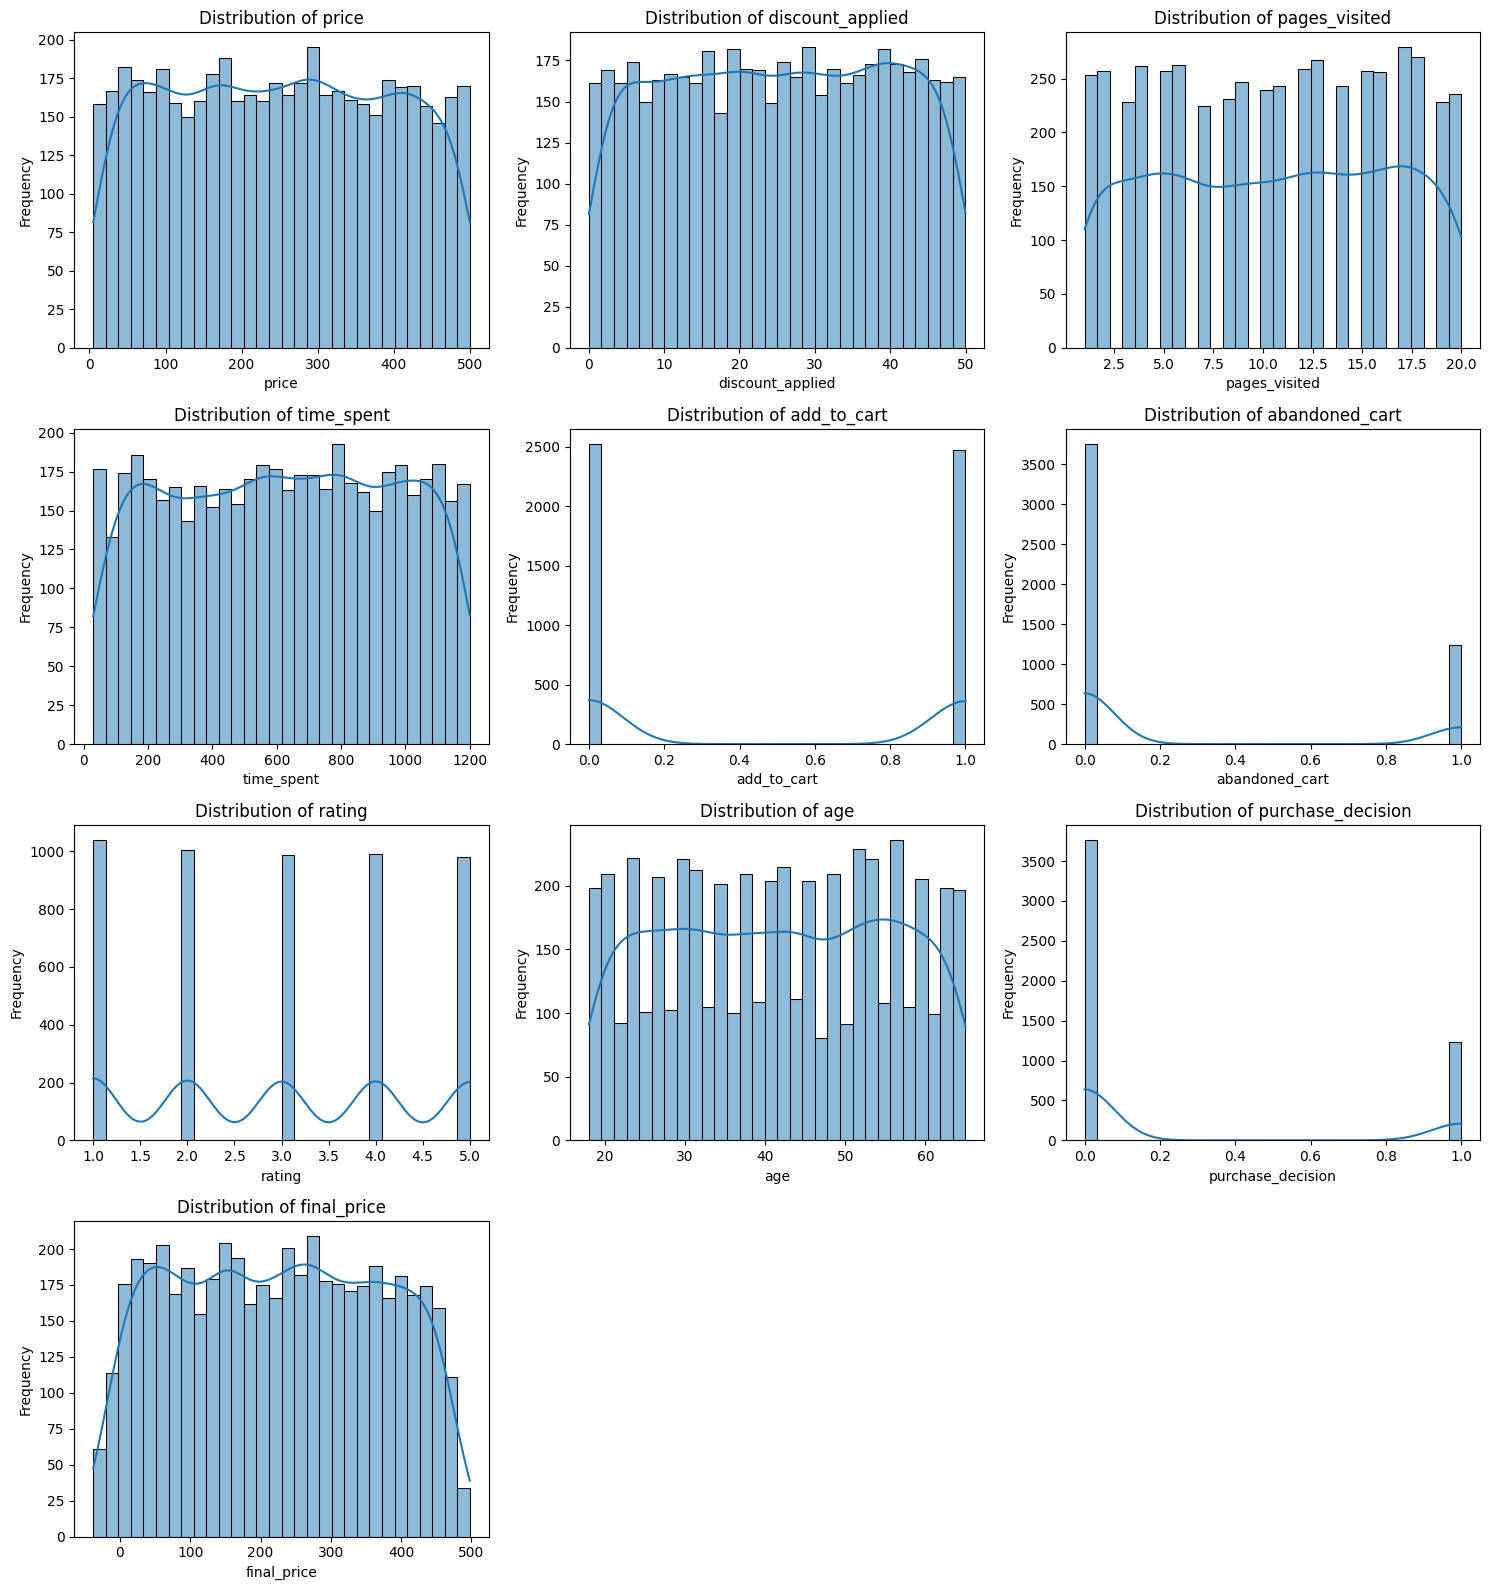

In [115]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

n_cols = 3
n_rows = (len(numerical_cols) + n_cols - 1) // n_cols

plt.figure(figsize=(n_cols * 5, n_rows * 4))
for i, col in enumerate(numerical_cols):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

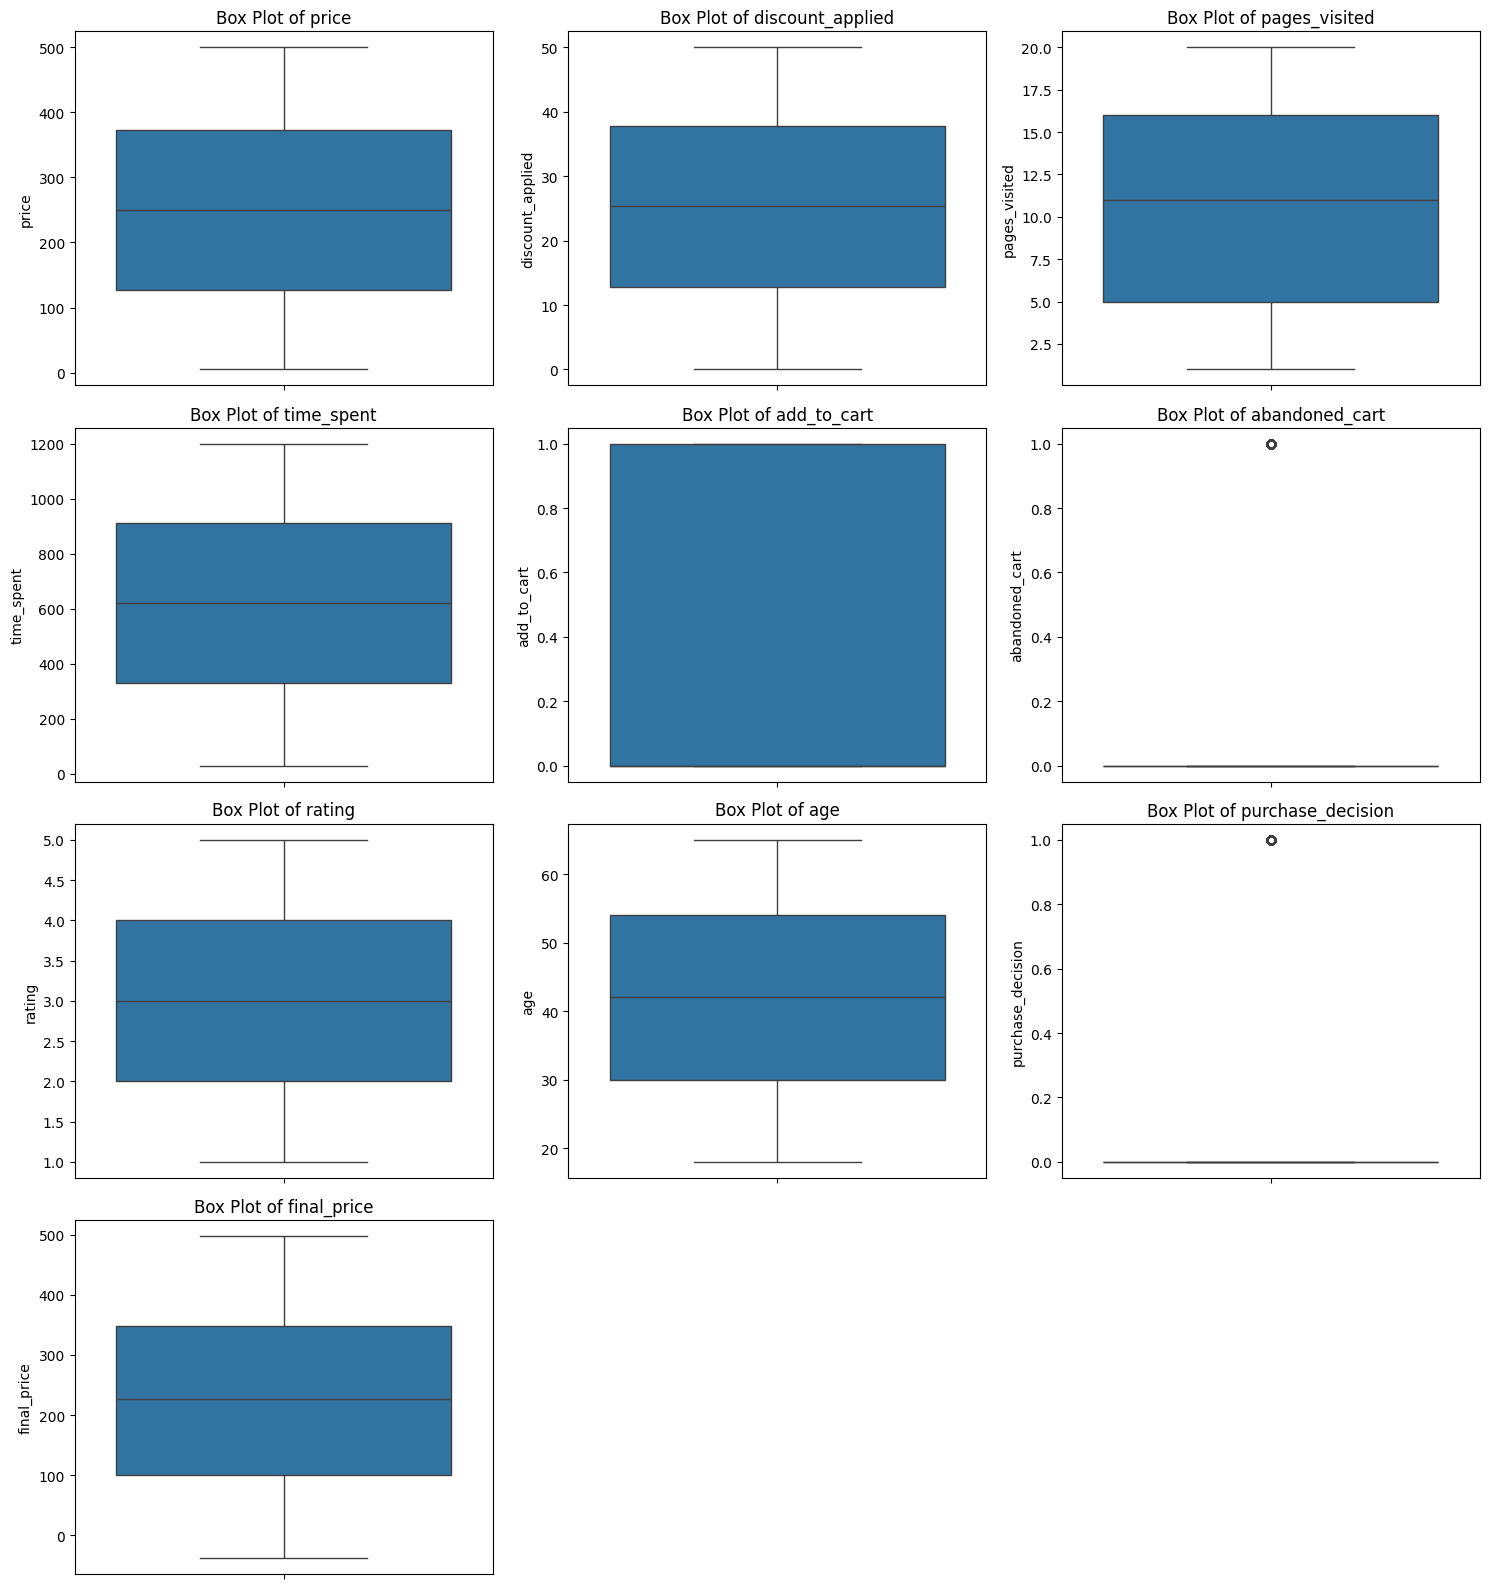

In [116]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

n_cols = 3
n_rows = (len(numerical_cols) + n_cols - 1) // n_cols

plt.figure(figsize=(n_cols * 5, n_rows * 4))
for i, col in enumerate(numerical_cols):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.boxplot(y=df[col])
    plt.title(f'Box Plot of {col}')
    plt.ylabel(col)

plt.tight_layout()
plt.show()

<Axes: xlabel='age', ylabel='Count'>

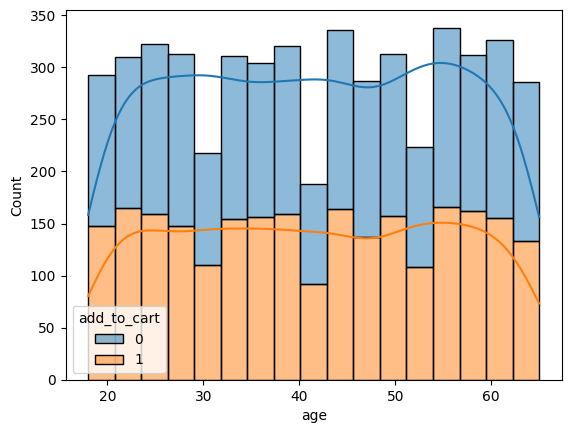

In [117]:
sns.histplot(data=df, x="age", hue="add_to_cart", multiple="stack", kde=True)

<Axes: xlabel='gender', ylabel='Count'>

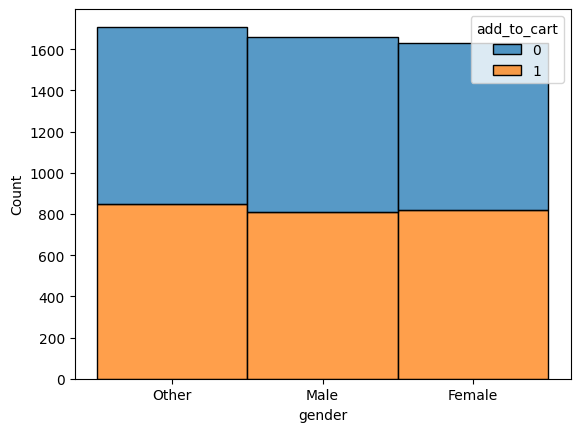

In [168]:
sns.histplot(data=df, x="gender", hue="add_to_cart", multiple="stack")

<Axes: xlabel='age', ylabel='Count'>

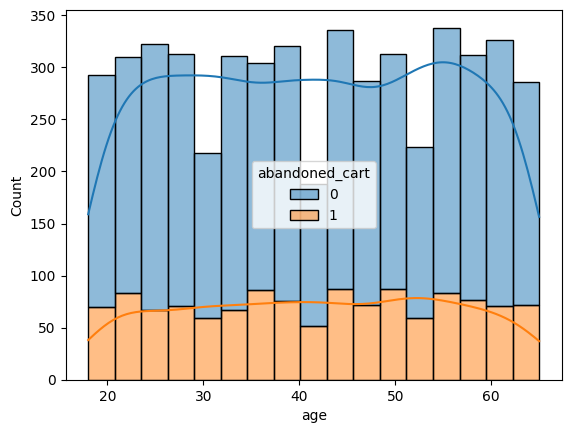

In [121]:
sns.histplot(data=df, x="age", hue="abandoned_cart", multiple="stack", kde=True)

<Axes: xlabel='gender', ylabel='Count'>

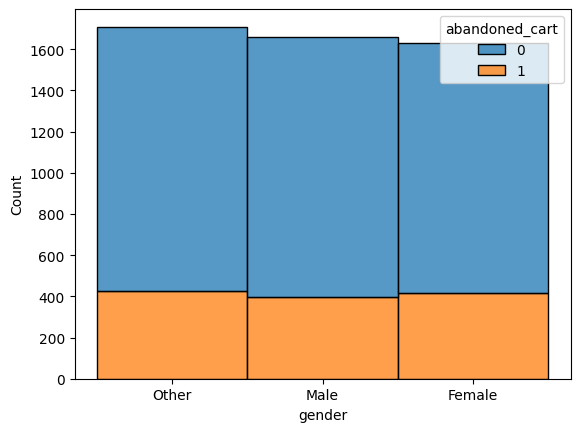

In [170]:
sns.histplot(data=df, x="gender", hue="abandoned_cart", multiple="stack")

<Axes: xlabel='age', ylabel='Count'>

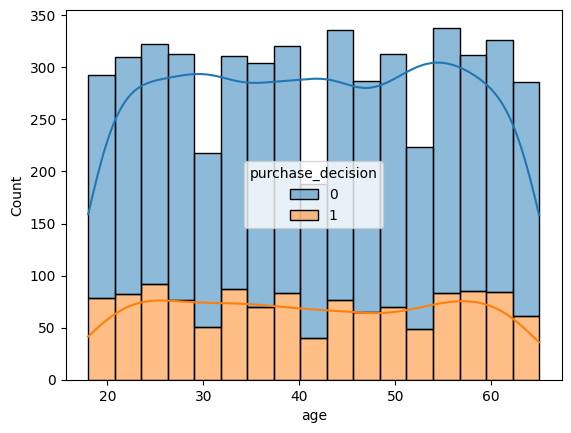

In [119]:
sns.histplot(data=df, x="age", hue="purchase_decision", multiple="stack", kde=True)

<Axes: xlabel='gender', ylabel='Count'>

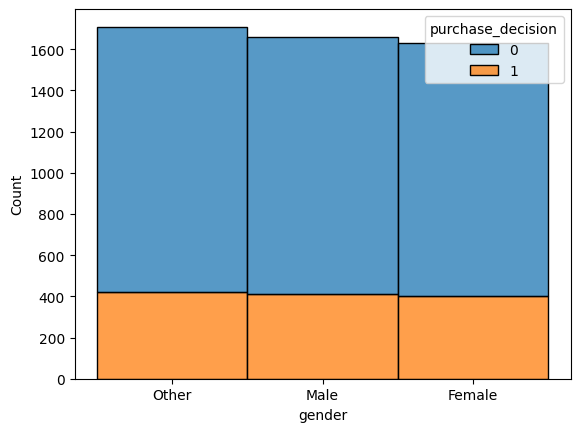

In [173]:
sns.histplot(data=df, x="gender", hue="purchase_decision", multiple="stack")

<Axes: xlabel='rating', ylabel='Count'>

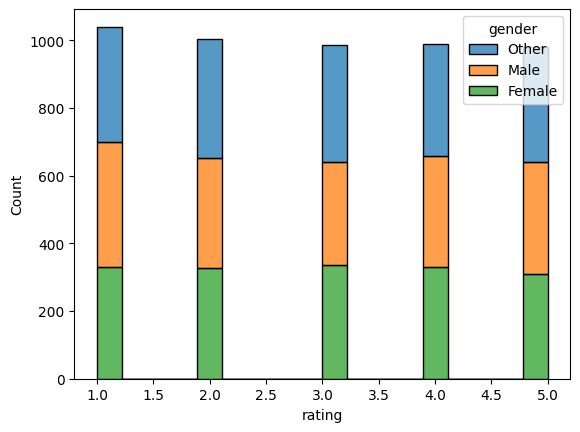

In [163]:
sns.histplot(data=df, x="rating", hue="gender", multiple="stack")

<Axes: xlabel='age', ylabel='Count'>

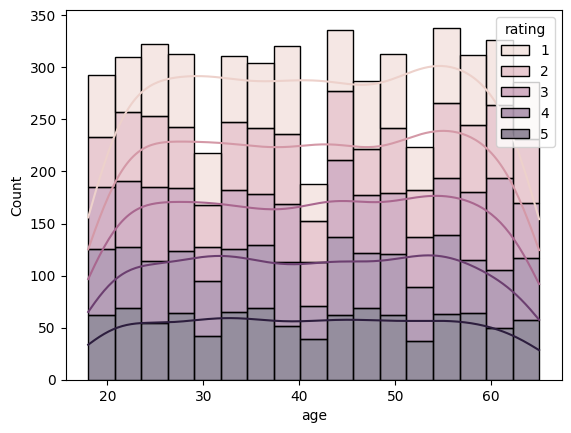

In [177]:
sns.histplot(data=df, x="age", hue="rating", multiple="stack", kde=True)

<Axes: xlabel='gender', ylabel='Count'>

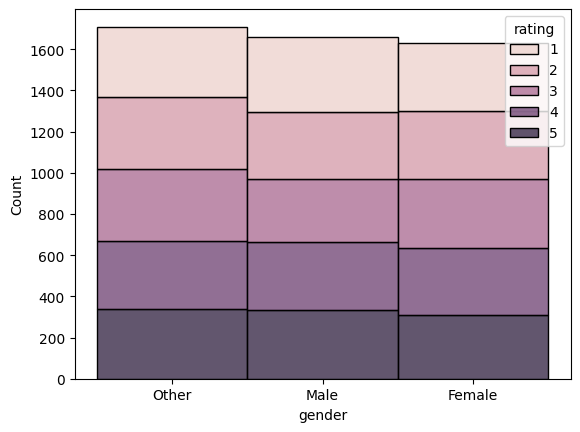

In [176]:
sns.histplot(data=df, x="gender", hue="rating", multiple="stack")

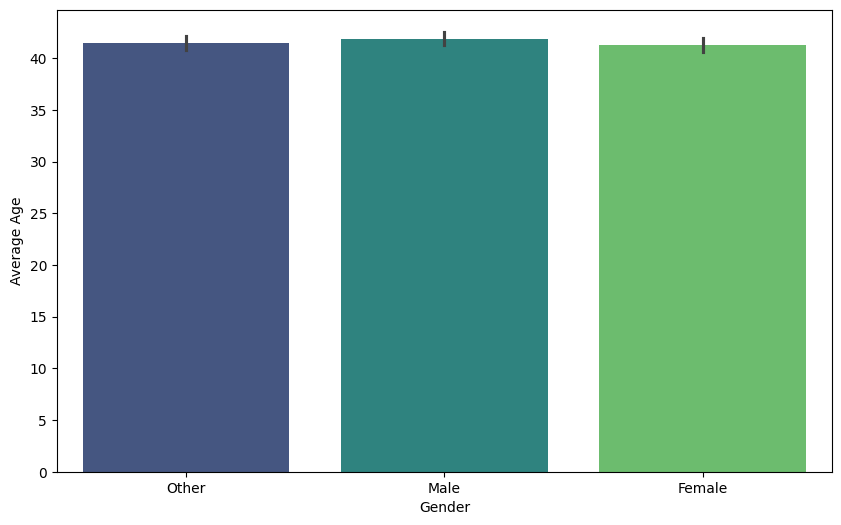

In [127]:
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='gender', y='age', hue='gender', palette='viridis', legend=False)
plt.xlabel('Gender')
plt.ylabel('Average Age')
plt.show()

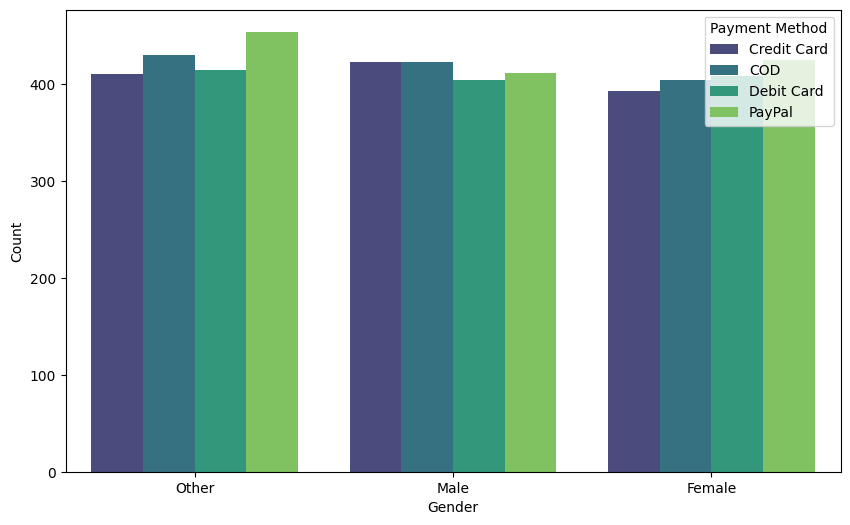

In [129]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='gender', hue='payment_method', palette='viridis')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.legend(title='Payment Method')
plt.show()

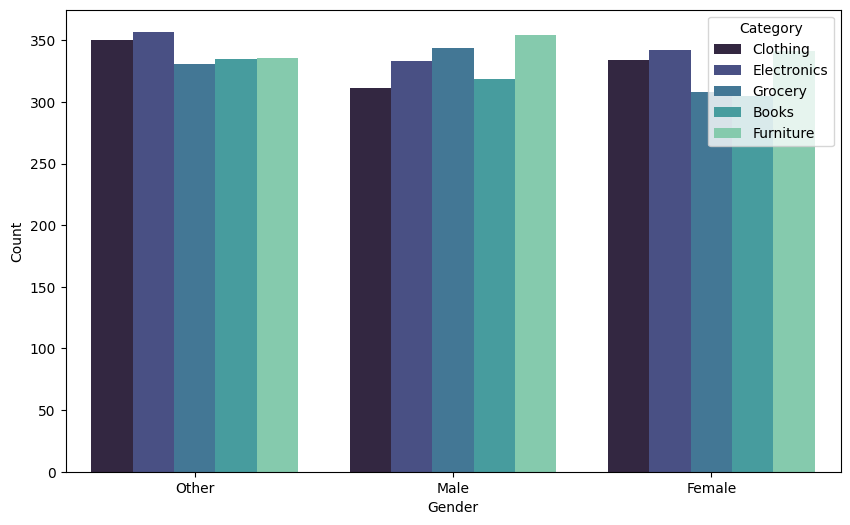

In [148]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='gender', hue='category', palette='mako')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.legend(title='Category')
plt.show()

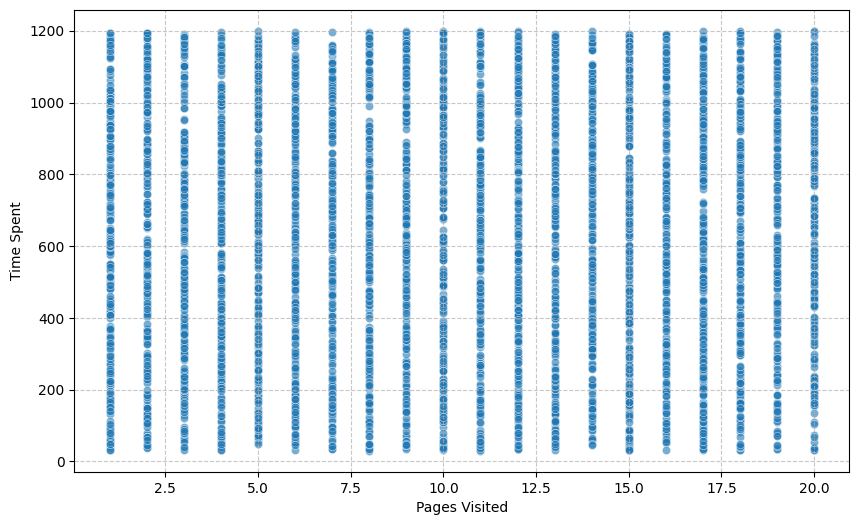

In [137]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='pages_visited', y='time_spent', alpha=0.6)
plt.xlabel('Pages Visited')
plt.ylabel('Time Spent')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [151]:
correlation = df['pages_visited'].corr(df['time_spent'])
print(f"Koefisien korelasi Pearson antara 'pages_visited' dan 'time_spent': {correlation:.2f}")

Koefisien korelasi Pearson antara 'pages_visited' dan 'time_spent': 0.02


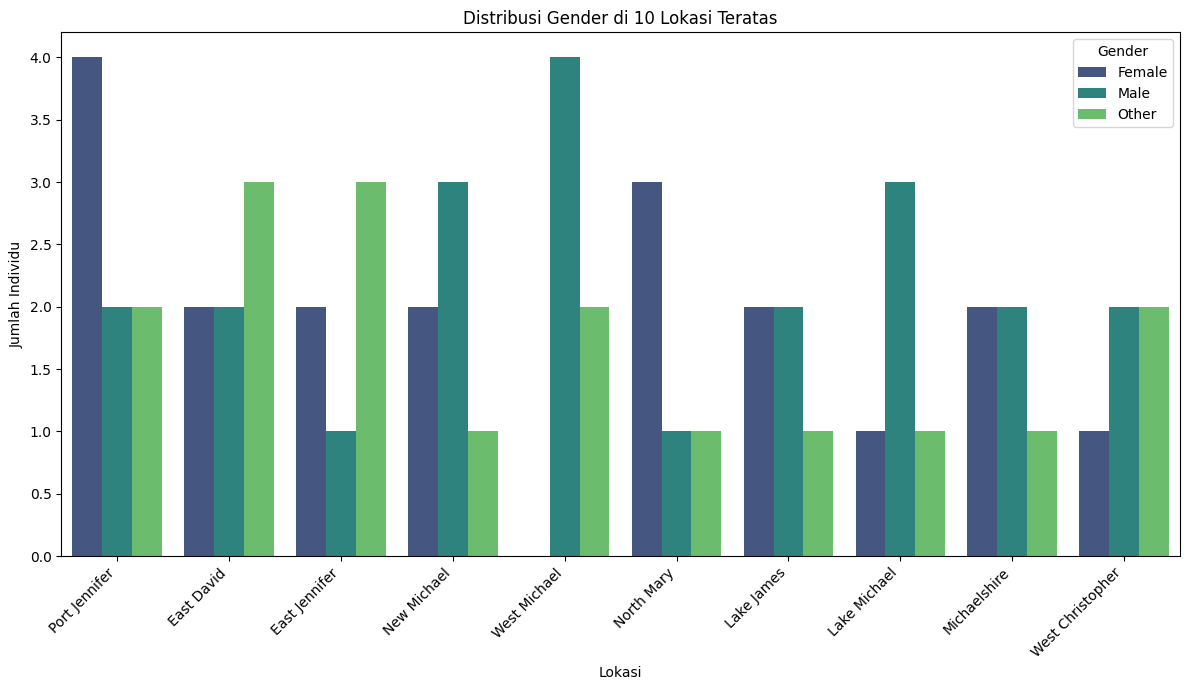

In [160]:
location_counts = contingency_table_all.sum(axis=1).sort_values(ascending=False)
top_10_locations = location_counts.head(10).index
contingency_table_top_10 = contingency_table_all.loc[top_10_locations]
df_top_10_melted = contingency_table_top_10.reset_index().melt(id_vars='location', var_name='gender', value_name='count')

plt.figure(figsize=(12, 7))
sns.barplot(data=df_top_10_melted, x='location', y='count', hue='gender', palette='viridis')
plt.title('Distribusi Gender di 10 Lokasi Teratas')
plt.xlabel('Lokasi')
plt.ylabel('Jumlah Individu')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Gender')
plt.tight_layout()
plt.show()

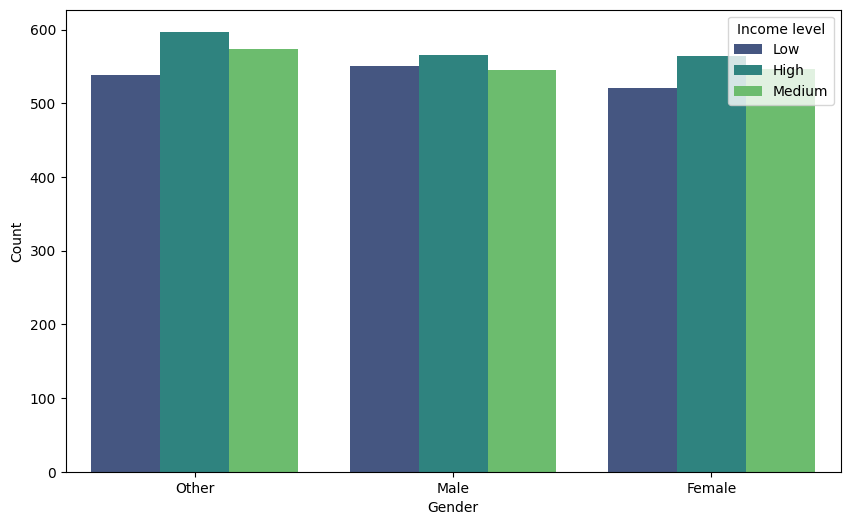

In [190]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='gender', hue='income_level', palette='viridis')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.legend(title='Income level')
plt.show()